In [552]:
def feature_plot(factual, counterfactual, feature_names, threshold=0.1,ax=None):
    # Plot setup
    colors = ['#0283F8', '#0078F3', '#3369E8', '#605BDA', "#7D49CB",
              "#9331B7", "#A918A8", "#C4009A", "#DA008B", "#EA007B",
              "#F7006A", "#FF0059"]
    
    filtered = [
        (f, o, u) for f, o, u in zip(feature_names, factual, counterfactual)
        if abs(u - o) >= threshold
    ]
    
    if not filtered:
        print("No features exceed the threshold.")
        return
    
    features_f, original_f, updated_f = zip(*filtered)
    y_positions = range(len(features_f))
    
    # Plot setup
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 0.5*len(filtered)))
    
    # Plot arrows and points for filtered features
    for y, orig, upd in zip(y_positions, original_f, updated_f):
        color = '#FF0059' if upd - orig > 0 else '#0283F8'
        
        # Draw arrow from original to updated
        ax.annotate('', xy=(upd, y), xytext=(orig, y),
                   arrowprops=dict(arrowstyle='->', 
                                 color='black', 
                                 lw=1.5,
                                 shrinkA=5,  # Shrink arrow start to not overlap with point
                                 shrinkB=5)) # Shrink arrow end to not overlap with point
        
        # Plot points
        ax.scatter(orig, y, color='black', s=50, zorder=2)
        ax.scatter(upd, y, color=color, s=50, zorder=2)
    
    # Formatting
    ax.set_yticks(y_positions)
    ax.set_yticklabels(features_f)
    ax.invert_yaxis()  # Highest feature at top
    ax.set_xlabel('Value')
    ax.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_ylim(-0.5, y_positions[-1]+0.5)
    #plt.show()
    


In [1]:
import torch
from defer.helpers.metrics import *
from defer.networks.linear_net import *
from defer.networks.non_linear_net import *
import torch.optim as optim
from defer.methods.realizable_surrogate import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import os
import sys
import os
import warnings
from contextlib import contextmanager

@contextmanager
def suppress_stdout_stderr():
    """A context manager that redirects stdout and stderr to devnull"""
    # Save the original stdout and stderr
    original_stdout = sys.stdout
    original_stderr = sys.stderr
    
    # Open the null device
    with open(os.devnull, 'w') as devnull:
        # Redirect stdout and stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield # This is where the code inside the 'with' block will run
        finally:
            # IMPORTANT: Always restore the original streams
            sys.stdout = original_stdout
            sys.stderr = original_stderr
            
import csv
import os

def append_dict_to_csv(csv_filepath, data_dict):
    """
    Appends a dictionary as a new row to a CSV file.

    - If the CSV file does not exist, it will be created, and the
      dictionary keys will be used as the header row.
    - If the CSV file exists, the dictionary values are appended
      as a new row. The keys are assumed to match the header.

    Args:
        csv_filepath (str): The path to the CSV file.
        data_dict (dict): The dictionary to write to the CSV.
    """
    # Check if the file exists to determine if we need to write the header
    file_exists = os.path.exists(csv_filepath)

    # Use 'a' mode for appending, which creates the file if it doesn't exist.
    # newline='' is critical to prevent blank rows from being written.
    with open(csv_filepath, 'a', newline='', encoding='utf-8') as f:
        # The fieldnames are the dictionary keys.
        # It's important that all dictionaries you write have the same keys.
        fieldnames = data_dict.keys()
        
        # Create a DictWriter object
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        # If the file is new, write the header row
        if not file_exists:
            writer.writeheader()

        # Write the dictionary as a new row
        writer.writerow(data_dict)
        
def append_df_to_csv(csv_filepath, df, index=False):
    """
    Appends a pandas DataFrame to a CSV file.

    - If the CSV file does not exist, it's created, and the DataFrame's
      column names are used as the header.
    - If the CSV file exists, the DataFrame's data is appended without
      writing a new header.

    Args:
        csv_filepath (str): The path to the CSV file.
        df (pd.DataFrame): The DataFrame to append.
        index (bool): Write DataFrame index as a column. Defaults to False.
    """
    # Check if the file exists to determine if the header needs to be written.
    header = not os.path.exists(csv_filepath)

    # Use pandas to_csv function with mode 'a' (append)
    # and the header parameter controlled by file existence.
    df.to_csv(
        csv_filepath, 
        mode='a', 
        header=header, 
        index=index,
        encoding='utf-8'
    )


def train_l2d_model(dataset, expert,method = "realizable_surrogate",defer_only=True):
    # Set up model training parameters
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    optimizer = optim.Adam
    scheduler = None
    lr = 1e-2
    total_epochs = 100
    # Create and train model
    model = NonLinearNet(dataset.d, 3).to(device)  # positive, negative, and defer
    # Instantiate method
    if method=="realizable_surrogate":
        L2D = RealizableSurrogate(1, 300, model, device, True)
    elif method== "crossentropy_surrogate": #lce
        L2D = LceSurrogate(1, 300, model, device)
    elif method== "one_vs_all":
        L2D = OVASurrogate(1, 300, model, device)
    else:
        print("Model has to be one of: realizable_surrogate, crossentropy_surrogate or one_vs_all")
        return None, {}, None, []
    L2D.fit_hyperparam(
        dataset.data_train_loader,
        dataset.data_val_loader,
        dataset.data_test_loader,
        epochs=total_epochs,
        optimizer=optimizer,
        scheduler=scheduler,
        lr=lr,
        verbose=False,
        test_interval=5,
    )
    # Get metrics
    metrics = compute_deferral_metrics(L2D.test(dataset.data_test_loader))
    factual_df, factuals = scripts.utils.build_factual_df(L2D,dataset,expert,defer_only=False)
    return L2D, metrics, factual_df, factuals


def obtain_counterfactuals(l2d,factuals,factual_df,metrics,expert):
    perturbations, counter_df = scripts.counterfactual.find_defer_counterfactuals_parallel(
        model=l2d.model,
        test_x=factuals,
        threshold_rej=0,
        n_jobs=-1 # Use all available cores
    )
    
    counter_df = scripts.utils.probe_counterfactuals(counter_df,perturbations,factuals,expert,l2d)
    df_merged = factual_df.join(counter_df[["cfs_entropy","cfs_expected_expert_err"]],how="inner")
    
    isTypeI = df_merged["entropy"] > df_merged["cfs_entropy"]
    isTypeII = df_merged["cfs_expected_expert_err"] > df_merged["expected_expert_err"]
    #model_was_correct = df_merged["model_pred"] == df_merged["label"]
    #expert_was_correct = df_merged["expert_pred"] == df_merged["label"]
    
    metrics["n_type1"] = np.sum(isTypeI)
    metrics["n_type2"] = np.sum(isTypeII)
    metrics["n_only_type1"] = np.sum(isTypeI & ~isTypeII)
    metrics["n_only_type2"] = np.sum(isTypeII & ~isTypeI)
    metrics["n_defer"] = df_merged.shape[0]
    return metrics,df_merged, perturbations


In [565]:
import numpy as np
from scipy.optimize import minimize
import scripts
from dataclasses import dataclass
import torch
import torch.nn.functional as F
from torch.optim import Adam


@dataclass
class EstimatedExpert:
    """Expert model with parameters compatible with expert_predict_proba function."""
    fpr_beta: float  # beta0 - false positive rate beta
    fnr_beta: float  # beta1 - false negative rate beta
    alpha: float     # scaling factor
    w: np.ndarray    # weight vector
    
    def __post_init__(self):
        """Ensure w is a numpy array."""
        self.w = np.asarray(self.w)


def estimate_expert_parameters(X, y, m, learning_rate=0.01, n_epochs=2000, verbose=False):
    """
    Estimate expert parameters using Maximum Likelihood Estimation with PyTorch and Adam.
    
    Parameters:
    -----------
    X : numpy.ndarray
        Feature matrix of shape (n_samples, n_features)
    y : numpy.ndarray
        True labels of shape (n_samples,), binary (0 or 1)
    m : numpy.ndarray
        Expert predictions of shape (n_samples,), binary (0 or 1)
    learning_rate : float
        Learning rate for Adam optimizer
    n_epochs : int
        Number of optimization epochs
    verbose : bool
        Whether to print optimization progress
    
    Returns:
    --------
    EstimatedExpert
        Expert object containing estimated parameters
    """
    # Convert to torch tensors
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.FloatTensor(y)
    m_tensor = torch.FloatTensor(m)
    
    n_samples, n_features = X.shape
    
    # Initialize parameters
    # Better initialization based on data statistics
    fp_rate = ((y == 0) & (m == 1)).sum() / (y == 0).sum()
    fn_rate = ((y == 1) & (m == 0)).sum() / (y == 1).sum()
    
    # Avoid extreme values in log
    fp_rate = np.clip(fp_rate, 0.01, 0.99)
    fn_rate = np.clip(fn_rate, 0.01, 0.99)
    
    beta0 = torch.tensor(np.log(fp_rate / (1 - fp_rate)), requires_grad=True)
    beta1 = torch.tensor(np.log(fn_rate / (1 - fn_rate)), requires_grad=True)
    alpha = torch.tensor(1.0, requires_grad=True)
    
    # Initialize w as unit vector
    w_init = np.random.randn(n_features)
    w_init = w_init / np.linalg.norm(w_init)
    w = torch.tensor(w_init, dtype=torch.float32, requires_grad=True)
    
    # Collect all parameters
    parameters = [beta0, beta1, alpha, w]
    
    # Setup optimizer
    optimizer = Adam(parameters, lr=learning_rate)
    
    # Training loop
    best_loss = float('inf')
    best_params = None
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        
        # Compute projections with numerical stability
        w_norm = torch.norm(w)
        w_norm = torch.clamp(w_norm, min=1e-6)  # Prevent division by zero
        
        projections = torch.matmul(X_tensor, w) / w_norm
        
        # Compute error probabilities using sigmoid
        p_fp_error = torch.sigmoid(beta0 + alpha * projections)  # P(m=1|y=0, x)
        p_fn_error = torch.sigmoid(beta1 - alpha * projections)  # P(m=0|y=1, x)
        
        # Compute log-likelihood
        # For negative class (y=0)
        neg_mask = (y_tensor == 0)
        neg_correct = neg_mask & (m_tensor == 0)  # Correct rejection
        neg_error = neg_mask & (m_tensor == 1)    # False positive
        
        # For positive class (y=1)
        pos_mask = (y_tensor == 1)
        pos_correct = pos_mask & (m_tensor == 1)  # Correct detection
        pos_error = pos_mask & (m_tensor == 0)    # False negative
        
        # Log-likelihood components
        ll_neg_correct = torch.sum(torch.log(1 - p_fp_error[neg_correct] + 1e-10))
        ll_neg_error = torch.sum(torch.log(p_fp_error[neg_error] + 1e-10))
        ll_pos_correct = torch.sum(torch.log(1 - p_fn_error[pos_correct] + 1e-10))
        ll_pos_error = torch.sum(torch.log(p_fn_error[pos_error] + 1e-10))
        
        log_likelihood = ll_neg_correct + ll_neg_error + ll_pos_correct + ll_pos_error
        
        # Add L2 regularization
        reg_strength = 0.01
        regularization = reg_strength * (
            beta0**2 + beta1**2 + alpha**2 + torch.sum(w**2)
        )
        
        # Total loss (negative log-likelihood + regularization)
        loss = -log_likelihood + regularization
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(parameters, max_norm=5.0)
        
        # Update parameters
        optimizer.step()
        
        # Constrain alpha to be positive
        with torch.no_grad():
            alpha.data = torch.clamp(alpha.data, min=0.1)
        
        # Save best parameters
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_params = {
                'beta0': beta0.detach().clone(),
                'beta1': beta1.detach().clone(),
                'alpha': alpha.detach().clone(),
                'w': w.detach().clone()
            }
        
        if verbose and epoch % 100 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.4f}")
    
    # Return EstimatedExpert with best parameters
    return EstimatedExpert(
        fpr_beta=best_params['beta0'].item(),
        fnr_beta=best_params['beta1'].item(),
        alpha=best_params['alpha'].item(),
        w=best_params['w'].numpy()
    )



import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def evaluate_expert_model(X, y, m, expert, ax=None,color='blue'):
    """
    Evaluate how well the estimated model explains the expert's decisions.
    
    Parameters:
    -----------
    X, y, m : arrays
        Features, true labels, and expert predictions
    expert : EstimatedExpert
        The estimated expert model
    ax : matplotlib.axes.Axes, optional
        If provided, plot ROC curve on this axes
    """
    
    # Convert to tensors
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.FloatTensor(y)
    m_tensor = torch.FloatTensor(m)
    w_tensor = torch.FloatTensor(expert.w)
    
    # Compute projections
    w_norm_sq = torch.sum(w_tensor * w_tensor)
    projections = torch.matmul(X_tensor, w_tensor) / w_norm_sq
    
    # Compute error probabilities
    p_fp = torch.sigmoid(expert.fpr_beta + expert.alpha * projections)
    p_fn = torch.sigmoid(expert.fnr_beta - expert.alpha * projections)
    
    # Compute probability of expert predicting 1
    p_expert_1 = torch.where(y_tensor == 0, p_fp, 1 - p_fn)
    
    # Compute metrics
    from sklearn.metrics import roc_auc_score, log_loss, roc_curve
    
    try:
        auc = roc_auc_score(m, p_expert_1.numpy())
        
        # Plot ROC curve if axes provided
        if ax is not None:
            fpr, tpr, _ = roc_curve(m, p_expert_1.numpy())
            ax.plot(fpr, tpr, '-', lw=2,color=color)
            
    except:
        auc = 0.5
        if ax is not None:
            ax.text(0.5, 0.5, 'Unable to compute ROC', 
                   ha='center', va='center', transform=ax.transAxes)
    
    # Compute log loss
    logloss = log_loss(m, p_expert_1.numpy())
    
    # Compute accuracy of probabilistic predictions
    pred_m = (p_expert_1 > 0.5).float()
    accuracy = (pred_m == m_tensor).float().mean().item()
    
    return {'auc':auc, 'log-loss':logloss, 'accuracy':accuracy}

from defer.datasetsdefer.broward import BrowardDataset
def load_broward_dataset():
    dataset = BrowardDataset("defer/data")
    broward_data = pd.read_csv(
            "defer/data/allDataBroward/BROWARD_CLEAN_SUBSET.csv"
        )
    broward_data = broward_data.drop(["block_num", "id", "two_year_recid"], axis=1)
    feature_names = broward_data.columns
    X_train, y_train, h_train = list(dataset.data_train_loader)[0]
    expert = estimate_expert_parameters(X_train.detach().numpy(), y_train.detach().numpy(), h_train.detach().numpy())
    return expert,dataset,feature_names

In [518]:
with suppress_stdout_stderr():
    expert,dataset,feature_names = load_broward_dataset()
    RS, metrics, factual_df, factuals = train_l2d_model(dataset, expert,defer_only=True) #no need for method we use RS
    metrics, counter_df, perturbations = obtain_counterfactuals(RS, factuals,factual_df, metrics, expert)
#append_df_to_csv(f"results/broward_realizable_surrogate.csv", counter_df)

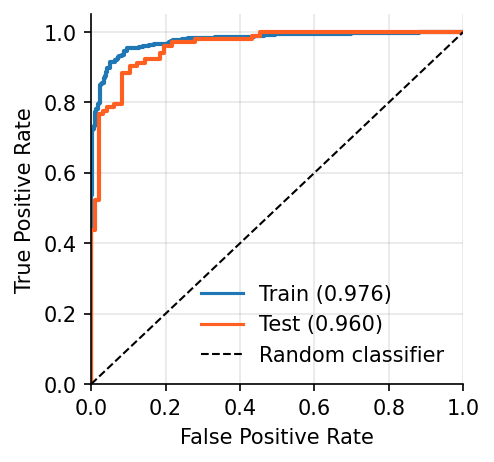

In [591]:
fig,ax = plt.subplots(figsize=(3.2,3.2),dpi=150)

for train_x, train_y, train_h in dataset.data_train_loader:
    train_rs = evaluate_expert_model(train_x.detach().numpy().astype(np.float32),
                                    train_y.detach().numpy().astype(np.float32),
                                    train_h.detach().numpy().astype(np.float32), expert,ax=ax,color="#1F77B4")
    
for test_x, test_y, test_h in dataset.data_test_loader:
    test_rs = evaluate_expert_model(test_x.detach().numpy().astype(np.float32),
                                    test_y.detach().numpy().astype(np.float32),
                                    test_h.detach().numpy().astype(np.float32), expert,ax=ax,color="#FF6021")

ax.plot([], [],label=f"Train ({train_rs['auc']:.3f})",color="#1F77B4")
ax.plot([], [],label=f"Test ({test_rs['auc']:.3f})",color="#FF6021")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.spines[['top','right']].set_visible(False)
ax.legend(loc="lower right",frameon=False)
ax.grid(True, alpha=0.3)
plt.savefig("results/broward_stats_roc.pdf",bbox_inches = 'tight')
plt.show()

In [585]:
data = pd.read_csv("results/broward_realizable_surrogate.csv")
data_defer=data[data["defer_score"]>0]
data_no=data[data["defer_score"]<=0]


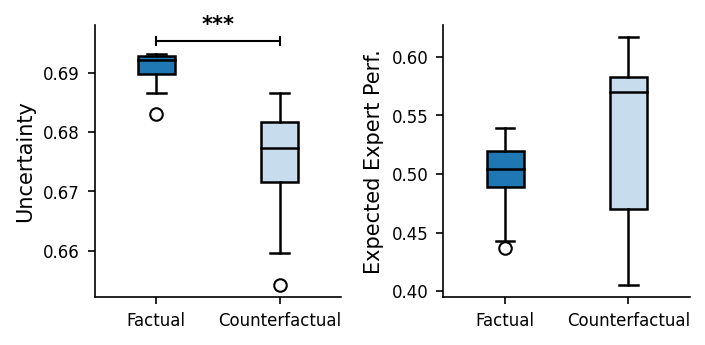

In [590]:
from scipy import stats
def add_statistical_significance_markers(dist1, dist2, ax, pos1=1, pos2=2):
    """
    Test two distributions and add statistical significance markers between them.
    
    Parameters:
    -----------
    dist1 : np.array
        First distribution data
    dist2 : np.array  
        Second distribution data
    ax : matplotlib.axes.Axes
        The axes object containing the boxplot
    pos1 : int or float
        Position of first box in the boxplot (default: 1)
    pos2 : int or float
        Position of second box in the boxplot (default: 2)
    
    Returns:
    --------
    dict : Dictionary with test results
    """
    
    # Perform Mann-Whitney U test
    statistic, p_value = stats.mannwhitneyu(dist1, dist2, alternative='two-sided')
    
    # Determine significance
    if p_value < 0.001:
        sig_marker = '***'
    elif p_value < 0.01:
        sig_marker = '**'
    elif p_value < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'ns'
    
    results = {
        'statistic': statistic,
        'p_value': p_value,
        'significance': sig_marker,
        'significant': p_value < 0.05
    }
    
    # Find max y value for positioning
    y_max = max(np.max(dist1), np.max(dist2))
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    y_offset = y_range * 0.05
    
    # Draw significance marker
    line_y = y_max + y_offset
    ax.plot([pos1, pos2], [line_y, line_y], 'k-', linewidth=1)
    
    # Add ticks
    tick_height = y_offset * 0.3
    ax.plot([pos1, pos1], [line_y - tick_height, line_y + tick_height], 'k-', linewidth=1)
    ax.plot([pos2, pos2], [line_y - tick_height, line_y + tick_height], 'k-', linewidth=1)
    
    # Add text
    mid_x = (pos1 + pos2) / 2
    ax.text(mid_x, line_y + y_offset * 0.5, sig_marker, 
           ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    return results




fig,ax = plt.subplot_mosaic("AB",figsize=(4.8,2.4),dpi=150)

bp1 = ax["A"].boxplot(
    [data_defer["entropy"],
    data_defer["cfs_entropy"]],
    labels=["Factual","Counterfactual"],
    widths=0.3,
    patch_artist=True
)

ax["A"].set_ylabel("Uncertainty")
ax["A"].spines[["top","right"]].set_visible(False)
results = add_statistical_significance_markers(data_defer["entropy"], data_defer["cfs_entropy"], ax["A"], pos1=1, pos2=2)


bp2 = ax["B"].boxplot(
    [1-data_defer["expected_expert_err"],
    1-data_defer["cfs_expected_expert_err"]],
    labels=["Factual","Counterfactual"],
    patch_artist=True,
    widths=0.3
)

# Color the boxplots (alternating colors for factual and counterfactual)
colors = ["#1F77B4", "#C7DDED"]
for bp in [bp1,bp2]:
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i % 2])
        patch.set_alpha(1)  # Make boxes more opaque
        patch.set_edgecolor('black')  # Black box outlines
        patch.set_linewidth(1.2)

    # Make all lines black
    for element in ['whiskers', 'caps', 'medians', 'fliers']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.2)
        
ax["B"].set_ylabel("Expected Expert Perf.")
ax["B"].spines[["top","right"]].set_visible(False)
ax["A"].tick_params(axis='both', labelsize=8)
ax["B"].tick_params(axis='both', labelsize=8)
#ax["A"].tick_params(axis='x', lab)
#ax["B"].tick_params(axis='x', labelrotation=45)
plt.savefig("results/broward_stats_boxplot.pdf",bbox_inches = 'tight')
plt.tight_layout()
plt.show()
    

{'classifier_all_acc': 0.62,
 'human_all_acc': 0.615,
 'coverage': 0.26,
 'classifier_nondeferred_acc': 0.75,
 'human_deferred_acc': 0.5675675675675675,
 'system_acc': 0.615,
 'n_type1': 48,
 'n_type2': 71,
 'n_only_type1': 41,
 'n_only_type2': 64,
 'n_defer': 138}

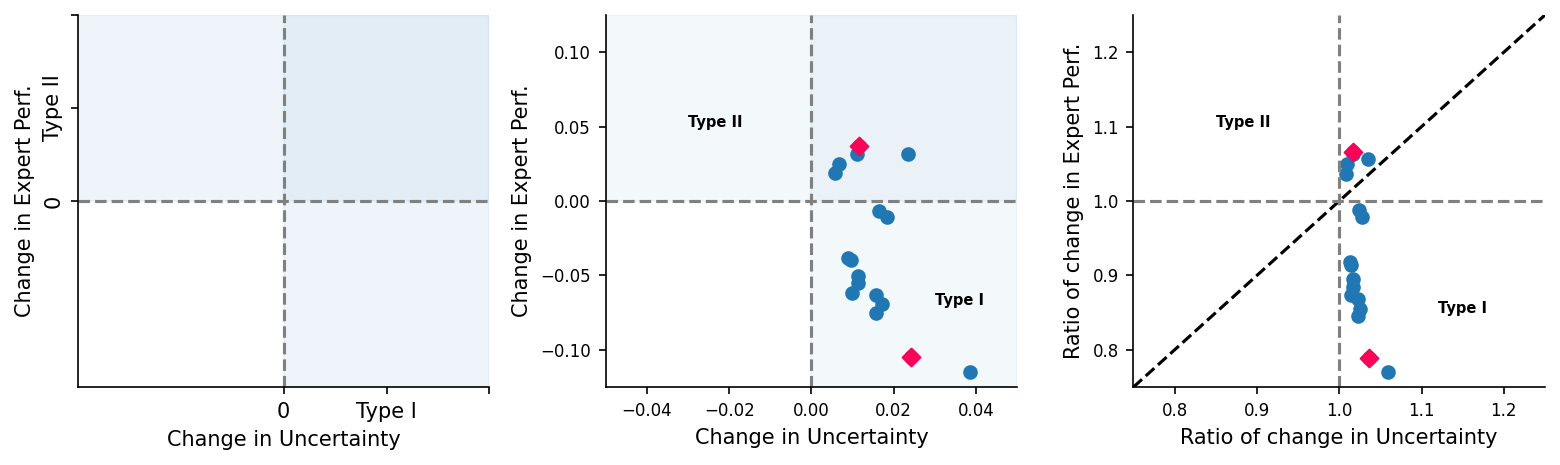

In [453]:

fig, ax=plt.subplot_mosaic("ABC",figsize=(10.5,3.2),dpi=150)
index = np.array([1,4])


ax["A"].set_xlabel("Change in Uncertainty")
ax["A"].set_ylabel("Change in Expert Perf.")
ax["A"].spines[["top","right"]].set_visible(False)
ax["A"].set_ylim(-1,1)
ax["A"].set_xlim(-1,1)

ax["A"].axvspan(0, 1, alpha=0.3, color='#C7DDED')
ax["A"].axhspan(0, 1, alpha=0.3, color='#C7DDED')
ax["A"].axvline(0,linestyle="--",color="gray")
ax["A"].axhline(0,linestyle="--",color="gray")
#ax["A"].annotate("$E_h(x) > E_h(x+\delta)$",(-0.5,0.5),fontsize=10,ha="center")
#ax.annotate("Less certain",(-0.5,-0.5),fontsize=7,ha="center")
#ax["A"].annotate("$E_h(x) > E_h(x+\delta)$ \n\n $U_m(x)>U_m(x+\delta)$",(0.5,0.5),fontsize=10,ha="center", va="center")
#ax["A"].annotate("$U_m(x)>U_m(x+\delta)$",(0.5,-0.5),fontsize=10,ha="center")
#ax.annotate("Type I",(0.5,-1),fontsize=12,weight="bold",ha="center")

#plt.legend(frameon=False)
ax["A"].set_yticks([0,0.5,1])
ax["A"].set_xticks([0,0.5,1])
ax["A"].set_xticklabels([0,"Type I",""])
ax["A"].set_yticklabels([0,"Type II",""],rotation=90,va="center")

#plt.savefig("results/fig2_coords_skeleton.pdf",bbox_inches = 'tight')



ax["B"].scatter(data_defer["entropy"]-data_defer["cfs_entropy"],
            data_defer["cfs_expected_expert_err"]-data_defer["expected_expert_err"],
           label="Defer",color="#1F77B4",zorder=1)
ax["B"].scatter(data_defer["entropy"].values[index]-data_defer["cfs_entropy"].values[index],
            data_defer["cfs_expected_expert_err"].values[index]-data_defer["expected_expert_err"].values[index],
          color="#FF0059",marker="D")


ax["B"].set_xlabel("Change in Uncertainty")
ax["B"].set_ylabel("Change in Expert Perf.")
ax["B"].spines[["top","right"]].set_visible(False)
ax["B"].set_xlim(-0.05,0.05)
ax["B"].set_ylim(-0.125,0.125)
x_min, x_max = ax["B"].get_xlim()
y_min, y_max = ax["B"].get_ylim()

# vertical band (Type I region): x > 0
ax["B"].axvspan(0, x_max, alpha=0.2, color="#C7DDED",zorder=-3)

# horizontal band (Type II region): y > 0
ax["B"].axhspan(0, y_max, alpha=0.2, color="#C7DDED",zorder=-3)
ax["B"].axvline(0,linestyle="--",color="gray")
ax["B"].axhline(0,linestyle="--",color="gray")
ax["B"].annotate("Type I",(0.03,-0.07),fontsize=7, weight="bold")
ax["B"].annotate("Type II",(-0.03,0.05),fontsize=7, weight="bold")
#plt.legend(frameon=False)
ax["B"].tick_params(axis='both', labelsize=8)
###

ax["C"].scatter(data_defer["entropy"]/data_defer["cfs_entropy"],
            data_defer["cfs_expected_expert_err"]/data_defer["expected_expert_err"],
           label="Defer",color="#1F77B4",zorder=1)

ax["C"].scatter(data_defer["entropy"].values[index]/data_defer["cfs_entropy"].values[index],
            data_defer["cfs_expected_expert_err"].values[index]/data_defer["expected_expert_err"].values[index],
          color="#FF0059",marker="D")


ax["C"].axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1.5, 
               label='x = y', zorder=2)
ax["C"].set_xlabel("Ratio of change in Uncertainty")
ax["C"].set_ylabel("Ratio of change in Expert Perf.")
ax["C"].spines[["top","right"]].set_visible(False)
#ax["C"].set_xlim(0.95,1.05)
ax["C"].set_xlim(0.75,1.25)
ax["C"].set_ylim(0.75,1.25)
x_min, x_max = ax["B"].get_xlim()
y_min, y_max = ax["B"].get_ylim()


ax["C"].axvline(1,linestyle="--",color="gray")
ax["C"].axhline(1,linestyle="--",color="gray")
ax["C"].annotate("Type I",(1.12,0.85),fontsize=7, weight="bold")
ax["C"].annotate("Type II",(0.85,1.1),fontsize=7, weight="bold")
#plt.legend(frameon=False)
ax["C"].tick_params(axis='both', labelsize=8)


plt.tight_layout()
#plt.savefig("results/broward_counterfactuals_skeleton.pdf",bbox_inches = 'tight')
plt.show()

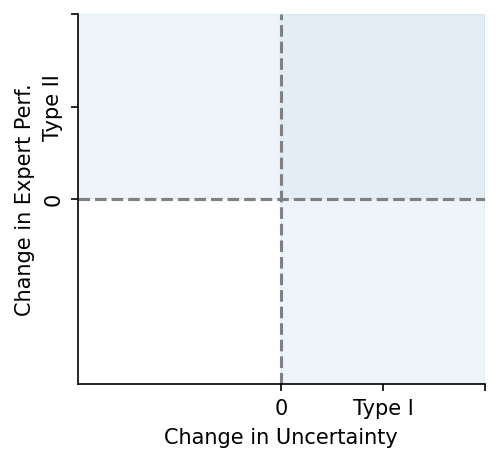

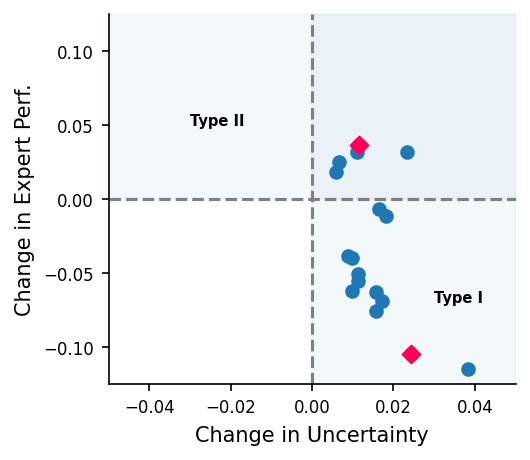

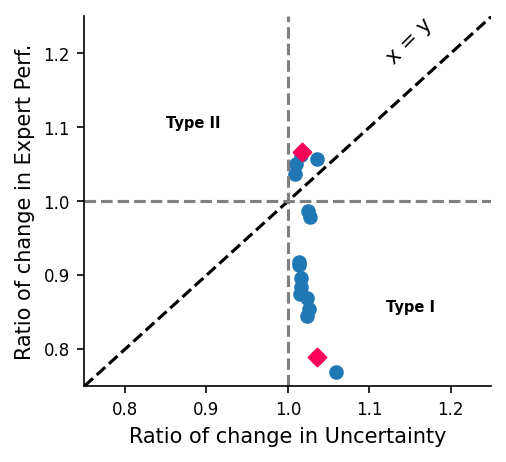

In [485]:
index = np.array([1,4])
fig, ax=plt.subplots(figsize=(3.5,3.2),dpi=150)


ax.set_xlabel("Change in Uncertainty")
ax.set_ylabel("Change in Expert Perf.")
ax.spines[["top","right"]].set_visible(False)
ax.set_ylim(-1,1)
ax.set_xlim(-1,1)

ax.axvspan(0, 1, alpha=0.3, color='#C7DDED')
ax.axhspan(0, 1, alpha=0.3, color='#C7DDED')
ax.axvline(0,linestyle="--",color="gray")
ax.axhline(0,linestyle="--",color="gray")

#plt.legend(frameon=False)
ax.set_yticks([0,0.5,1])
ax.set_xticks([0,0.5,1])
ax.set_xticklabels([0,"Type I",""])
ax.set_yticklabels([0,"Type II",""],rotation=90,va="center")

plt.savefig("results/broward_counterfactuals_skeleton_A.pdf",bbox_inches = 'tight')
plt.show()

##############

fig, ax=plt.subplots(figsize=(3.5,3.2),dpi=150)

ax.scatter(data_defer["entropy"]-data_defer["cfs_entropy"],
            data_defer["cfs_expected_expert_err"]-data_defer["expected_expert_err"],
           label="Defer",color="#1F77B4",zorder=1)
ax.scatter(data_defer["entropy"].values[index]-data_defer["cfs_entropy"].values[index],
            data_defer["cfs_expected_expert_err"].values[index]-data_defer["expected_expert_err"].values[index],
          color="#FF0059",marker="D")


ax.set_xlabel("Change in Uncertainty")
ax.set_ylabel("Change in Expert Perf.")
ax.spines[["top","right"]].set_visible(False)
ax.set_xlim(-0.05,0.05)
ax.set_ylim(-0.125,0.125)
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# vertical band (Type I region): x > 0
ax.axvspan(0, x_max, alpha=0.2, color="#C7DDED",zorder=-3)

# horizontal band (Type II region): y > 0
ax.axhspan(0, y_max, alpha=0.2, color="#C7DDED",zorder=-3)
ax.axvline(0,linestyle="--",color="gray")
ax.axhline(0,linestyle="--",color="gray")
ax.annotate("Type I",(0.03,-0.07),fontsize=7, weight="bold")
ax.annotate("Type II",(-0.03,0.05),fontsize=7, weight="bold")
#plt.legend(frameon=False)
ax.tick_params(axis='both', labelsize=8)
plt.savefig("results/broward_counterfactuals_skeleton_B.pdf",bbox_inches = 'tight')

plt.show()

######

fig, ax=plt.subplots(figsize=(3.5,3.2),dpi=150)

ax.scatter(data_defer["entropy"]/data_defer["cfs_entropy"],
            data_defer["cfs_expected_expert_err"]/data_defer["expected_expert_err"],
           label="Defer",color="#1F77B4",zorder=1)

ax.scatter(data_defer["entropy"].values[index]/data_defer["cfs_entropy"].values[index],
            data_defer["cfs_expected_expert_err"].values[index]/data_defer["expected_expert_err"].values[index],
          color="#FF0059",marker="D")


ax.axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1.5, 
               label='x = y', zorder=2)
ax.set_xlabel("Ratio of change in Uncertainty")
ax.set_ylabel("Ratio of change in Expert Perf.")
ax.spines[["top","right"]].set_visible(False)
#ax["C"].set_xlim(0.95,1.05)
ax.set_xlim(0.75,1.25)
ax.set_ylim(0.75,1.25)
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()


ax.axvline(1,linestyle="--",color="gray")
ax.axhline(1,linestyle="--",color="gray")
ax.annotate("Type I",(1.12,0.85),fontsize=7, weight="bold")
ax.annotate("Type II",(0.85,1.1),fontsize=7, weight="bold")
ax.text(1.15, 1.18, 'x = y', rotation=45, 
             ha='center', va='bottom', 
             fontsize=10, color='black',
             zorder=3)
#plt.legend(frameon=False)
ax.tick_params(axis='both', labelsize=8)


#plt.tight_layout()
plt.savefig("results/broward_counterfactuals_skeleton_C.pdf",bbox_inches = 'tight')
plt.show()

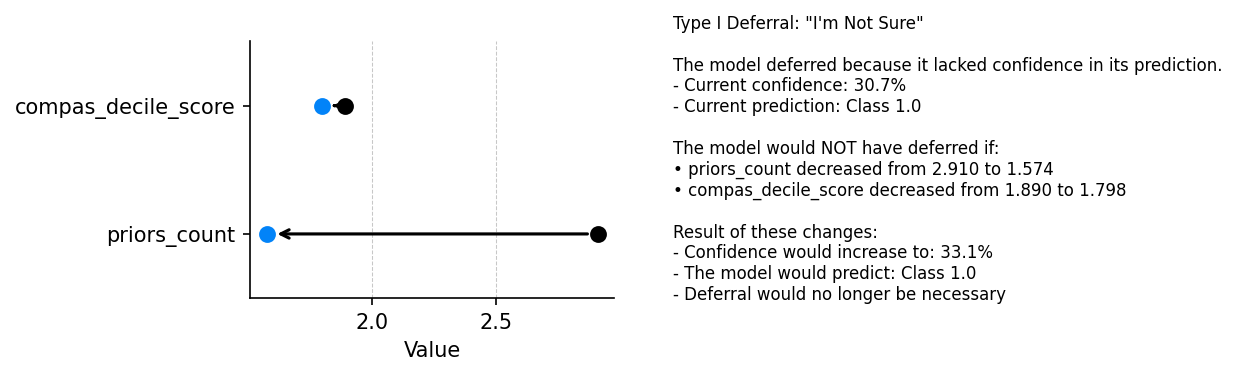

In [486]:
mosaic = """
AB
"""


index = 1


fig,ax = plt.subplot_mosaic(mosaic,figsize=(8, 2.5),dpi=150)

###################


feature_plot(factuals[index].detach().numpy(),
             factuals[index].detach().numpy() + perturbations[index].detach().numpy().flatten()
             , feature_names,threshold=0.08,ax=ax["A"])


##################
result = generate_deferral_explanation(
    data_defer.iloc[index].to_dict(),
    factuals[index].detach().numpy(),
    factuals[index].detach().numpy() + perturbations[index].detach().numpy().flatten(),
    feature_names,feature_change_threshold=0.08
)


ax["B"].text(0.1, 0.5,  # x, y coordinates
        result['explanation'],
        # Horizontal alignment
        va='center',        # Vertical alignment
        fontsize=8,
        color='black',
        transform=ax["B"].transAxes, # Use axis coordinates
        #bbox=dict(
        #    boxstyle='round,pad=0.5', # The box shape and padding
        #    facecolor='white',       # The box's background color
        #    edgecolor='black',       # The box's border color
        #    alpha=1                # The transparency of the box
        #)
            )

# 3. Turn off the axis
# This hides the x and y axes, ticks, and labels.
ax["B"].axis('off')
ax["A"].scatter([],[],color="black",label="Factual")
#ax["A"].legend(frameon=False)
# 4. Display the plot
plt.tight_layout()
plt.savefig("results/broward_explanation_typeI.pdf",bbox_inches = 'tight')
plt.show()

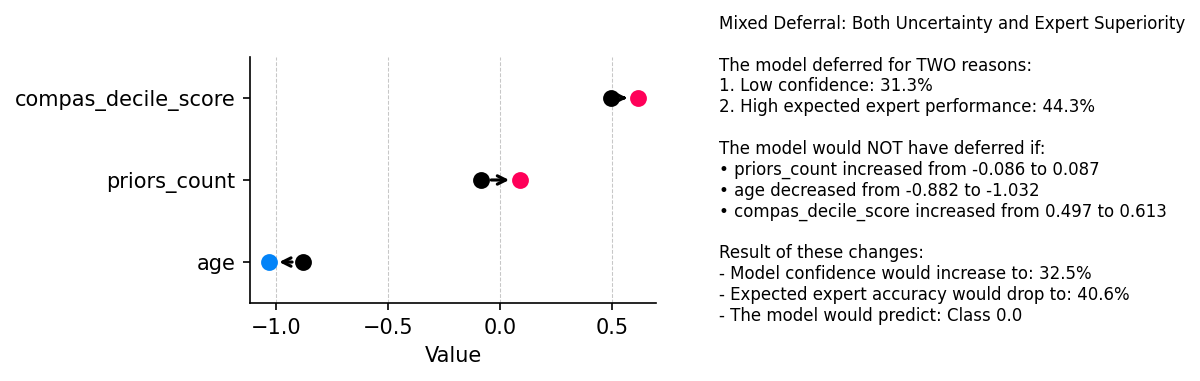

In [487]:
index = 4

mosaic = """
AB
"""



fig,ax = plt.subplot_mosaic(mosaic,figsize=(8, 2.5),dpi=150)



feature_plot(factuals[index].detach().numpy(),
             factuals[index].detach().numpy() + perturbations[index].detach().numpy().flatten()
             , feature_names,threshold=0.08,ax=ax["A"])


##################
result = generate_deferral_explanation(
    data_defer.iloc[index].to_dict(),
    factuals[index].detach().numpy(),
    factuals[index].detach().numpy() + perturbations[index].detach().numpy().flatten(),
    feature_names,feature_change_threshold=0.08
)


ax["B"].text(0.1, 0.5,  # x, y coordinates
        result['explanation'],
        # Horizontal alignment
        va='center',        # Vertical alignment
        fontsize=8,
        color='black',
        transform=ax["B"].transAxes, # Use axis coordinates
        #bbox=dict(
        #    boxstyle='round,pad=0.5', # The box shape and padding
        #    facecolor='white',       # The box's background color
        #    edgecolor='black',       # The box's border color
        #    alpha=1                # The transparency of the box
        #)
            )

# 3. Turn off the axis
# This hides the x and y axes, ticks, and labels.
ax["B"].axis('off')

# 4. Display the plot
plt.tight_layout()
plt.savefig("results/broward_explanation_typeMix.pdf",bbox_inches = 'tight')
plt.show()

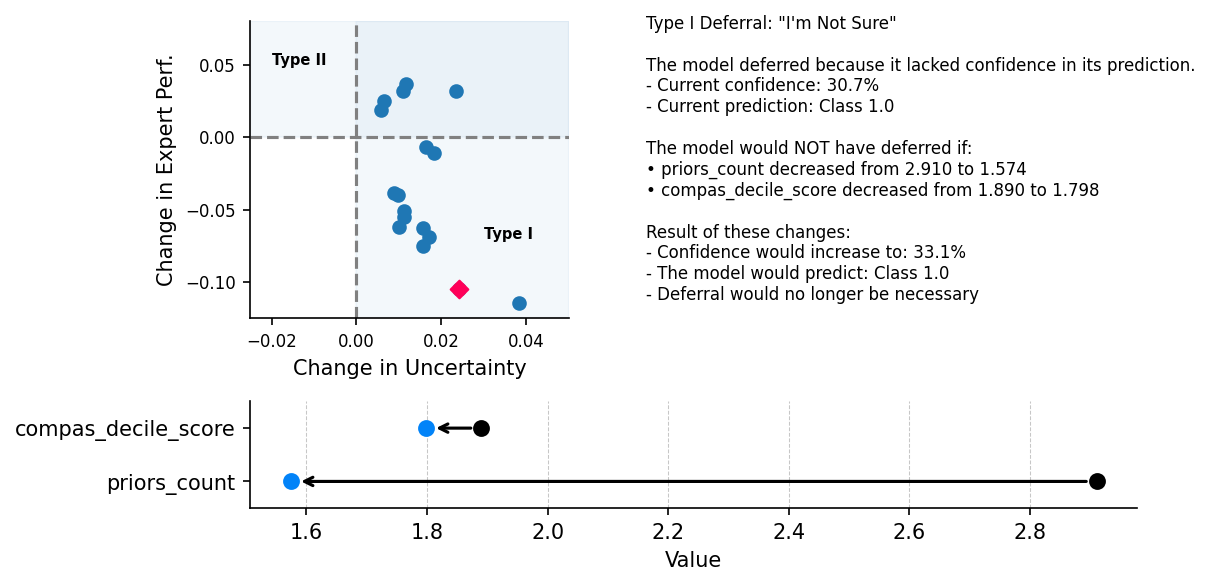

In [400]:
mosaic = """
AAABBBBB
AAABBBBB
CCCCCCCC
"""


index = 1


fig,ax = plt.subplot_mosaic(mosaic,figsize=(8, 4),dpi=150)

ax["A"].scatter(data_defer["entropy"]-data_defer["cfs_entropy"],
            data_defer["cfs_expected_expert_err"]-data_defer["expected_expert_err"],
           label="Defer",color="#1F77B4",zorder=1)

ax["A"].scatter(data_defer["entropy"].values[index]-data_defer["cfs_entropy"].values[index],
            data_defer["cfs_expected_expert_err"].values[index]-data_defer["expected_expert_err"].values[index],
          color="#FF0059",marker="D")


ax["A"].set_xlabel("Change in Uncertainty")
ax["A"].set_ylabel("Change in Expert Perf.")
ax["A"].spines[["top","right"]].set_visible(False)
ax["A"].set_xlim(-0.025,0.05)
ax["A"].set_ylim(-0.125,0.08)
x_min, x_max = ax["A"].get_xlim()
y_min, y_max = ax["A"].get_ylim()

# vertical band (Type I region): x > 0
ax["A"].axvspan(0, x_max, alpha=0.2, color="#C7DDED",zorder=-3)

# horizontal band (Type II region): y > 0
ax["A"].axhspan(0, y_max, alpha=0.2, color="#C7DDED",zorder=-3)
ax["A"].axvline(0,linestyle="--",color="gray")
ax["A"].axhline(0,linestyle="--",color="gray")
ax["A"].annotate("Type I",(0.03,-0.07),fontsize=7, weight="bold")
ax["A"].annotate("Type II",(-0.02,0.05),fontsize=7, weight="bold")
#plt.legend(frameon=False)
ax["A"].tick_params(axis='both', labelsize=8)

###################


feature_plot(factuals[index].detach().numpy(),
             factuals[index].detach().numpy() + perturbations[index].detach().numpy().flatten()
             , feature_names,threshold=0.08,ax=ax["C"])


##################
result = generate_deferral_explanation(
    data_defer.iloc[index].to_dict(),
    factuals[index].detach().numpy(),
    factuals[index].detach().numpy() + perturbations[index].detach().numpy().flatten(),
    feature_names,feature_change_threshold=0.08
)


ax["B"].text(0.1, 0.5,  # x, y coordinates
        result['explanation'],
        # Horizontal alignment
        va='center',        # Vertical alignment
        fontsize=8,
        color='black',
        transform=ax["B"].transAxes, # Use axis coordinates
        #bbox=dict(
        #    boxstyle='round,pad=0.5', # The box shape and padding
        #    facecolor='white',       # The box's background color
        #    edgecolor='black',       # The box's border color
        #    alpha=1                # The transparency of the box
        #)
            )

# 3. Turn off the axis
# This hides the x and y axes, ticks, and labels.
ax["B"].axis('off')

# 4. Display the plot
plt.tight_layout()
plt.savefig("results/broward_explanation_typeI.pdf",bbox_inches = 'tight')
plt.show()

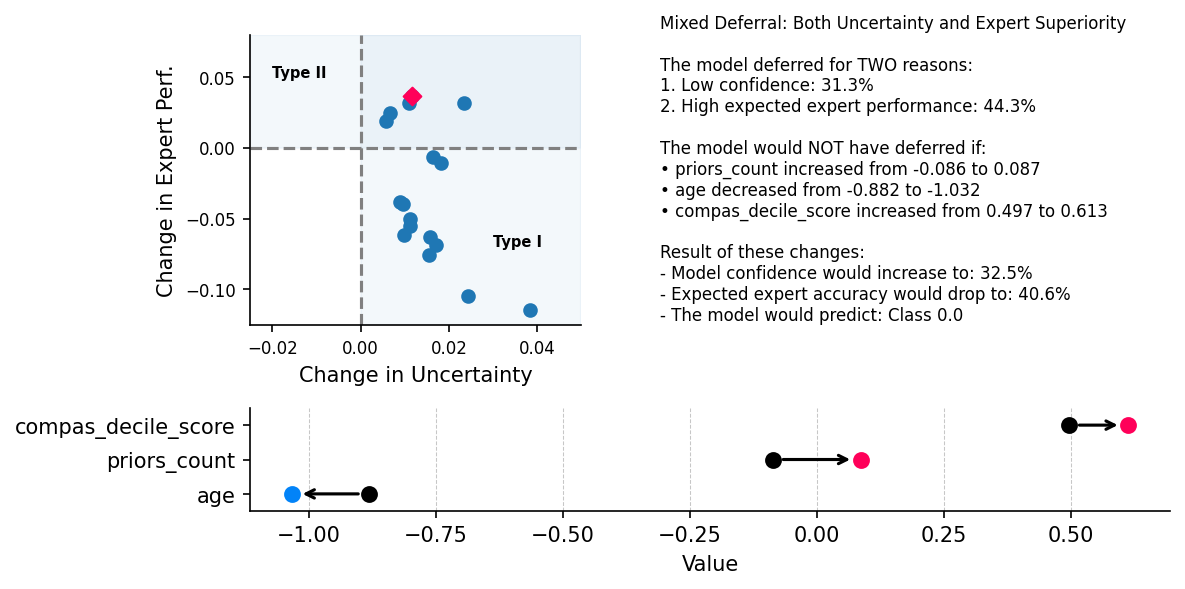

In [402]:
index = 4

mosaic = """
AAABBBBB
AAABBBBB
CCCCCCCC
"""



fig,ax = plt.subplot_mosaic(mosaic,figsize=(8, 4),dpi=150)

ax["A"].scatter(data_defer["entropy"]-data_defer["cfs_entropy"],
            data_defer["cfs_expected_expert_err"]-data_defer["expected_expert_err"],
           label="Defer",color="#1F77B4",zorder=1)

ax["A"].scatter(data_defer["entropy"].values[index]-data_defer["cfs_entropy"].values[index],
            data_defer["cfs_expected_expert_err"].values[index]-data_defer["expected_expert_err"].values[index],
          color="#FF0059",marker="D")


ax["A"].set_xlabel("Change in Uncertainty")
ax["A"].set_ylabel("Change in Expert Perf.")
ax["A"].spines[["top","right"]].set_visible(False)
ax["A"].set_xlim(-0.025,0.05)
ax["A"].set_ylim(-0.125,0.08)
x_min, x_max = ax["A"].get_xlim()
y_min, y_max = ax["A"].get_ylim()

# vertical band (Type I region): x > 0
ax["A"].axvspan(0, x_max, alpha=0.2, color="#C7DDED",zorder=-3)

# horizontal band (Type II region): y > 0
ax["A"].axhspan(0, y_max, alpha=0.2, color="#C7DDED",zorder=-3)
ax["A"].axvline(0,linestyle="--",color="gray")
ax["A"].axhline(0,linestyle="--",color="gray")
ax["A"].annotate("Type I",(0.03,-0.07),fontsize=7, weight="bold")
ax["A"].annotate("Type II",(-0.02,0.05),fontsize=7, weight="bold")
#plt.legend(frameon=False)
ax["A"].tick_params(axis='both', labelsize=8)

###################


feature_plot(factuals[index].detach().numpy(),
             factuals[index].detach().numpy() + perturbations[index].detach().numpy().flatten()
             , feature_names,threshold=0.08,ax=ax["C"])


##################
result = generate_deferral_explanation(
    data_defer.iloc[index].to_dict(),
    factuals[index].detach().numpy(),
    factuals[index].detach().numpy() + perturbations[index].detach().numpy().flatten(),
    feature_names,feature_change_threshold=0.08
)


ax["B"].text(0.1, 0.5,  # x, y coordinates
        result['explanation'],
        # Horizontal alignment
        va='center',        # Vertical alignment
        fontsize=8,
        color='black',
        transform=ax["B"].transAxes, # Use axis coordinates
        #bbox=dict(
        #    boxstyle='round,pad=0.5', # The box shape and padding
        #    facecolor='white',       # The box's background color
        #    edgecolor='black',       # The box's border color
        #    alpha=1                # The transparency of the box
        #)
            )

# 3. Turn off the axis
# This hides the x and y axes, ticks, and labels.
ax["B"].axis('off')

# 4. Display the plot
plt.tight_layout()
plt.savefig("results/broward_explanation_typeMix.pdf",bbox_inches = 'tight')
plt.show()

In [307]:
def generate_deferral_explanation(data, factual, counterfactual, feature_names, 
                                 feature_change_threshold=0.1):
    """
    Explain the deferral decision by describing what specific changes would have 
    prevented it, contextualized by the type of deferral.
    
    Parameters:
    -----------
    data : dict
        Contains all the metrics
    factual : array-like
        Original feature values
    counterfactual : array-like
        Counterfactual feature values
    feature_names : list
        Names of features
    feature_change_threshold : float
        Minimum absolute change to report a feature (default: 0.1)
    """
    
    # Calculate confidence values (confidence = 1 - entropy)
    confidence_factual = 1 - data['entropy']
    confidence_counterfactual = 1 - data['cfs_entropy']
    
    # Calculate expected expert performance (performance = 1 - error)
    expert_perf_factual = 1 - data['expected_expert_err']
    expert_perf_counterfactual = 1 - data['cfs_expected_expert_err']
    
    # Find what actually changed in the counterfactual (with threshold)
    feature_changes = []
    for fname, f_val, cf_val in zip(feature_names, factual, counterfactual):
        change = cf_val - f_val
        if abs(change) >= feature_change_threshold:  # Use threshold
            feature_changes.append({
                'name': fname,
                'original': f_val,
                'counterfactual': cf_val,
                'change': change,
                'abs_change': abs(change)
            })
    
    # Sort by absolute change
    feature_changes.sort(key=lambda x: x['abs_change'], reverse=True)
    
    # Determine deferral type based on the paper's criteria
    type_i = data['entropy'] > data['cfs_entropy']  # Confidence increased in counterfactual
    type_ii = data['cfs_expected_expert_err'] > data['expected_expert_err']  # Expert performance decreased in counterfactual
    
    if type_i and type_ii:
        defer_type = 'mixed'
    elif type_i:
        defer_type = 1  # Type I: "I'm Not Sure"
    elif type_ii:
        defer_type = 2  # Type II: "You Know Better"
    else:
        defer_type = 'unclear'
    
    # Generate explanation based on type
    explanation = ""
    
    if not feature_changes:
        explanation = f"No features changed by more than {feature_change_threshold}. The deferral boundary is extremely sensitive."
        return {
            'type': defer_type,
            'explanation': explanation,
            'feature_changes': [],
            'metrics': {
                'confidence_factual': confidence_factual,
                'confidence_counterfactual': confidence_counterfactual,
                'expert_perf_factual': expert_perf_factual,
                'expert_perf_counterfactual': expert_perf_counterfactual,
                'defer_score': data['defer_score']
            }
        }
    
    if defer_type == 1:
        explanation = f"""Type I Deferral: "I'm Not Sure"

The model deferred because it lacked confidence in its prediction.
- Current confidence: {confidence_factual:.1%}
- Current prediction: Class {data['model_pred']}

The model would NOT have deferred if:"""
        
        for feat in feature_changes[:5]:
            direction = "increased" if feat['change'] > 0 else "decreased"
            explanation += f"\n• {feat['name']} {direction} from {feat['original']:.3f} to {feat['counterfactual']:.3f}"
        
        explanation += f"""

Result of these changes:
- Confidence would increase to: {confidence_counterfactual:.1%}
- The model would predict: Class {data['model_pred']}
- Deferral would no longer be necessary
"""

    elif defer_type == 2:
        explanation = f"""Type II Deferral: "You Know Better"

The model deferred because it estimates the expert would perform better on this instance.
- Model's expected expert accuracy here: {expert_perf_factual:.1%}
- Model would predict: Class {data['model_pred']} (but defers to expert)

The model would NOT have deferred if:"""
        
        for feat in feature_changes[:5]:
            direction = "increased" if feat['change'] > 0 else "decreased"
            explanation += f"\n• {feat['name']} {direction} from {feat['original']:.3f} to {feat['counterfactual']:.3f}"
        
        explanation += f"""

Result of these changes:
- Expected expert accuracy would drop to: {expert_perf_counterfactual:.1%}
- Model confidence: {confidence_counterfactual:.1%}
- The model would take over and predict: Class {data['model_pred']}
"""

    elif defer_type == 'mixed':
        explanation = f"""Mixed Deferral: Both Uncertainty and Expert Superiority

The model deferred for TWO reasons:
1. Low confidence: {confidence_factual:.1%}
2. High expected expert performance: {expert_perf_factual:.1%}

The model would NOT have deferred if:"""
        
        for feat in feature_changes[:5]:
            direction = "increased" if feat['change'] > 0 else "decreased"
            explanation += f"\n• {feat['name']} {direction} from {feat['original']:.3f} to {feat['counterfactual']:.3f}"
        
        explanation += f"""

Result of these changes:
- Model confidence would increase to: {confidence_counterfactual:.1%}
- Expected expert accuracy would drop to: {expert_perf_counterfactual:.1%}
- The model would predict: Class {data['model_pred']}
"""

    else:  # unclear case
        explanation = f"""**Unclear Deferral Type**

The counterfactual shows minimal changes in both confidence and expected expert performance.

Changes that would prevent deferral:"""
        
        for feat in feature_changes[:5]:
            direction = "increased" if feat['change'] > 0 else "decreased"
            explanation += f"\n• {feat['name']} {direction} from {feat['original']:.3f} to {feat['counterfactual']:.3f}"
    
    # Add context about number of features that changed
    if len(feature_changes) > 5:
        explanation += f"\n\n(Note: {len(feature_changes)} features changed significantly, showing top 5)"
    
    
    return {
        'type': defer_type,
        'explanation': explanation,
        'feature_changes': feature_changes,
        'metrics': {
            'confidence_factual': confidence_factual,
            'confidence_counterfactual': confidence_counterfactual,
            'expert_perf_factual': expert_perf_factual,
            'expert_perf_counterfactual': expert_perf_counterfactual,
            'defer_score': data['defer_score']
        }
    }